# Lecture 2 — Class Exercise
# Bar Charts: World Happiness Report 2023

---

> **Your task:** Create **2 polished bar charts** using the World Happiness Report dataset.  
> **Push to:** `week02/lecture02_exercise.ipynb` in **your own GitHub repo** before the end of class.

---

### Rules (these will be checked in the model answer review next week)
1. Every bar chart **must have a zero baseline** — no exceptions (SWD p.51)
2. Every chart **must have an insight title**, not a topic title (SWD p.29)
3. Aim for **professional quality** — clean background, readable font, no clutter
4. Horizontal bars for long category names (SWD p.57)

---


## Setup — Run this cell first


In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('/content/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

---
## Task 1 — Regional Comparison Bar Chart

**What to build:** A horizontal bar chart showing the **average happiness score by region**, sorted from highest to lowest.

**Requirements:**
- Horizontal orientation (category names are long)
- Sorted by score, descending (so the happiest region is at the top)
- Zero baseline on x-axis
- At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
- An insight title that answers: *which region stands out and why does it matter?*

**Hint:** Use `df.groupby('Region')['Happiness_Score'].mean()` to compute the averages.


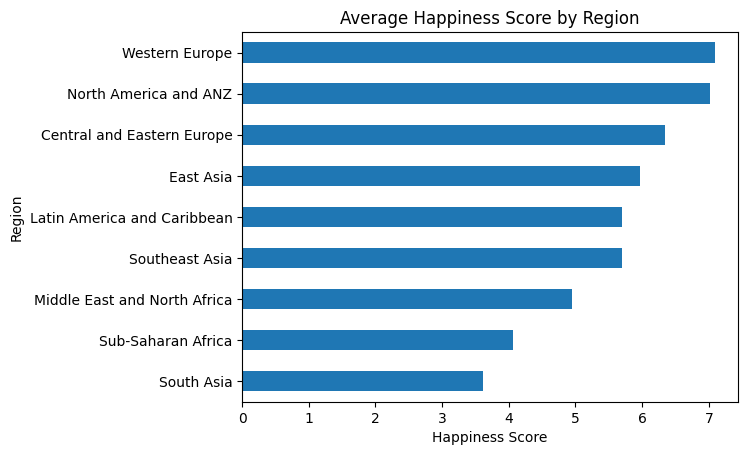

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("world_happiness_2023.csv")

# Group by region and calculate mean happiness score
region_avg = df.groupby("Regional indicator")["Ladder score"].mean().sort_values()

# Plot
plt.figure()
region_avg.plot(kind="barh")
plt.title("Average Happiness Score by Region")
plt.xlabel("Happiness Score")
plt.ylabel("Region")
plt.show()



---
## Task 2 — Bottom vs. Top: A Contrast Story

**What to build:** A bar chart that highlights the **gap between the happiest and least happy countries**, focusing on a specific insight.

**Requirements:**
- Show the **top 8 AND bottom 8 countries** together (16 bars total)
- Use **colour** to distinguish the two groups (not Plotly's default rainbow)
- Add a **visual separator or annotation** that emphasises the gap
- Insight title that tells the story of the gap

**Hint:** Use `pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')])` to get both groups.

**Stretch goal:** Add a vertical reference line showing the global average.


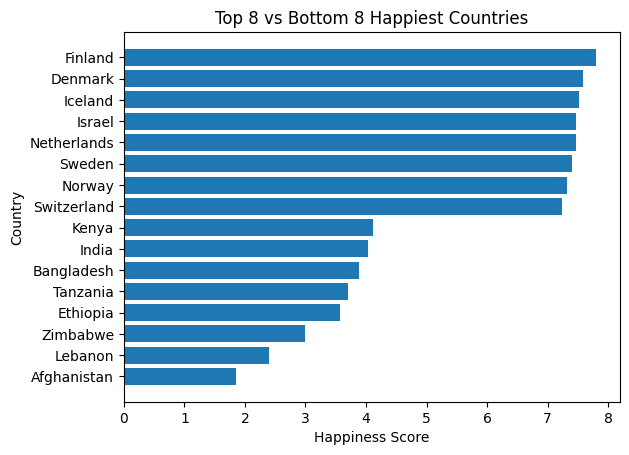

In [4]:
# Sort by happiness score
sorted_df = df.sort_values("Ladder score")

# Bottom 8 and Top 8
bottom8 = sorted_df.head(8)
top8 = sorted_df.tail(8)

# Combine
combined = pd.concat([bottom8, top8])

# Plot
plt.figure()
plt.barh(combined["Country name"], combined["Ladder score"])
plt.title("Top 8 vs Bottom 8 Happiest Countries")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.show()


---
## Done? Stretch Goal

If you finish both tasks with time to spare, try this:

**Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: `'Western Europe'`, `'Latin America'`, `'East Asia'`, `'Sub-Saharan Africa'`, `'South Asia'`


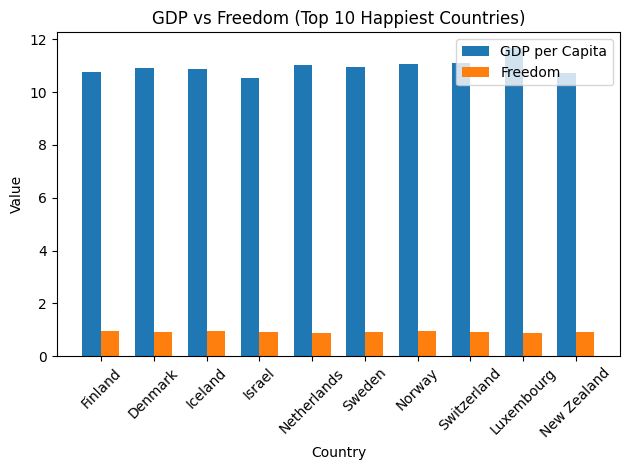

In [5]:
import numpy as np

# Select top 10 happiest countries
top10 = df.sort_values("Ladder score", ascending=False).head(10)

x = np.arange(len(top10))
width = 0.35

plt.figure()
plt.bar(x - width/2, top10["Logged GDP per capita"], width, label="GDP per Capita")
plt.bar(x + width/2, top10["Freedom to make life choices"], width, label="Freedom")

plt.xticks(x, top10["Country name"], rotation=45)
plt.title("GDP vs Freedom (Top 10 Happiest Countries)")
plt.xlabel("Country")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


OVERVIEW: Happiness varies significantly by region, with more developed areas showing higher average scores than less developed ones.
The gap between the happiest and least happy countries is large, reflecting differences in economic stability and social conditions.
While high GDP is common among the top countries, freedom to make life choices also plays a key role in higher happiness levels.
Overall, happiness is influenced by a mix of wealth, freedom, and strong social support systems rather than a single factor.